# Changing the temporal frecuency of returns

## Amazon case

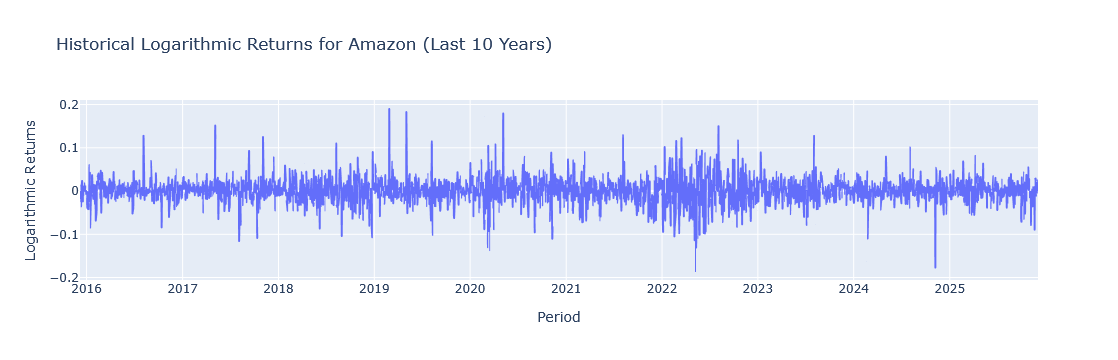

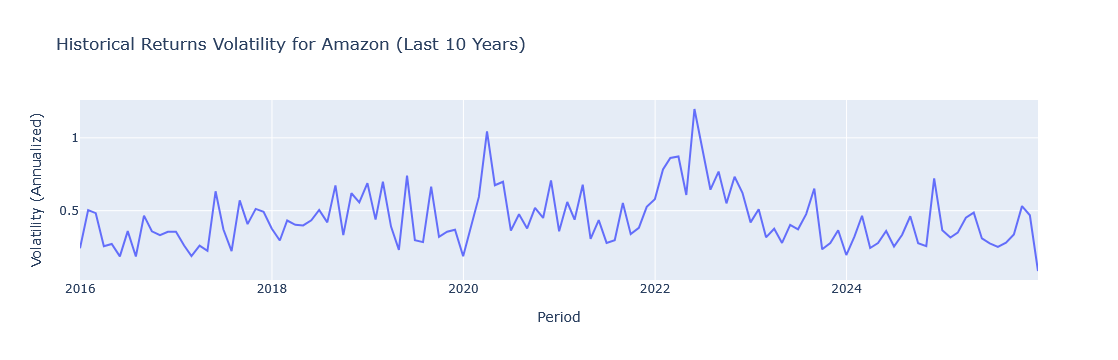

In [11]:
# 1.Import required libraries
import plotly.express as px
import pandas as pd 
import yfinance as yf
import numpy as np
import warnings
from datetime import datetime
from dateutil.relativedelta import relativedelta
#2. Set variables
start_date = datetime.now()- relativedelta(years=10)
end_date   = datetime.now()
ticker='MELI'
#2. Download data from Yahoo Finance 

df = yf.download(ticker, 
                 start=start_date.strftime('%Y-%m-%d'),
                 end=end_date.strftime('%Y-%m-%d'),
                 auto_adjust=False,
                 progress=False)

# 3. Keep only the adjusted close price

df = df.loc[:, ['Adj Close']]
df.rename(columns={'Adj Close': 'adj_close'}, inplace=True)

# 4. Calculate logarithmic returns

df['log_rtn'] = np.log(df.adj_close/df.adj_close.shift(1))

#5. Remove redundant data
df.drop('adj_close', axis=1, inplace=True)
df.dropna(axis=0, inplace=True)

#6. Define the function to calculate realized volatility


def realized_volatility(x):
    return np.sqrt(np.sum(x**2,axis=0))

#7. Calculate monthly realized volatility


df_rv = df.groupby(pd.Grouper(freq='ME')).apply(realized_volatility)
df_rv.rename(columns={'log_rtn': 'rv'}, inplace=True)

#8. Annualize the values

df_rv.rv = df_rv.rv * np.sqrt(12)

#  9. Plot the results

fig_rtn = px.line(
    df,
    x=df.index,
    y='log_rtn',
    title='Historical Logarithmic Returns for Amazon (Last 10 Years)',
    labels={'log_rtn': 'Logarithmic Returns',  'Date': 'Period'}
)
fig_rtn.update_traces(hovertemplate='%{y:.4f}<extra></extra>') # Tooltip format
fig_rtn.show()


fig_rv = px.line(
    df_rv,
    x=df_rv.index,
    y='rv',
    title='Historical Returns Volatility for Amazon (Last 10 Years)',
    labels={'rv': 'Volatility (Annualized)', 'Date': 'Period'}
)
fig_rv.update_traces(hovertemplate='%{y:.4f}<extra></extra>') # Tooltip format
fig_rv.show()